In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Cargar el dataset
df = pd.read_csv('datasets/games.csv')

# Mostrar información general
print("Información general del dataset:")
print(df.info())
print("\nPrimeras filas del dataset:")
print(df.head())
print("\nEstadísticas descriptivas:")
print(df.describe())

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None

Primeras filas del dataset:
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Su

In [2]:
# Convertir nombres de columnas a minúsculas
df.columns = df.columns.str.lower()
print("Nombres de columnas en minúsculas:")
print(df.columns)

Nombres de columnas en minúsculas:
Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [3]:
# Reemplazar 'tbd' en user_score por NaN y convertir a float
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)

# Convertir year_of_release a entero, manejando valores ausentes
df['year_of_release'] = df['year_of_release'].fillna(-1).astype(int)
df['year_of_release'] = df['year_of_release'].replace(-1, np.nan)

# Verificar tipos de datos
print("Tipos de datos después de la conversión:")
print(df.dtypes)

Tipos de datos después de la conversión:
name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object


user_score : Reemplazado "tbd" por np.nan para indicar valores ausentes y convertir la columna en float , ya que las evaluaciones de usuarios son numéricas (máximo 10).
Year_of_release : Convertí la columna a int , pero primero rellené los valores ausentes con -1 (para evitar errores) y luego los revertí a np.nan . Los años deben ser enteros, no flotantes.
Valores ausentes 
nombre y género : Hay pocos valores ausentes, así que elimina estas filas, ya que son esenciales para el análisis.
Year_of_release : También elimina filas con años ausentes, ya que el análisis depende del tiempo.

In [4]:
# Calcular ventas totales y agregarlas como nueva columna
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Verificar nueva columna
print("Primeras filas con ventas totales:")
print(df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())

Primeras filas con ventas totales:
                       name  na_sales  eu_sales  jp_sales  other_sales  \
0                Wii Sports     41.36     28.96      3.77         8.45   
1         Super Mario Bros.     29.08      3.58      6.81         0.77   
2            Mario Kart Wii     15.68     12.76      3.79         3.29   
3         Wii Sports Resort     15.61     10.93      3.28         2.95   
4  Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  


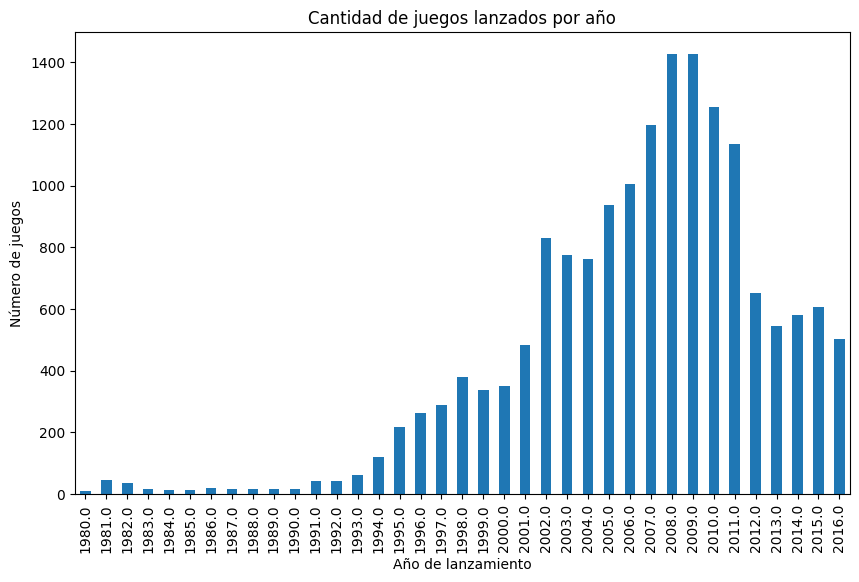

In [5]:
# Contar juegos por año
games_per_year = df.groupby('year_of_release').size()

# Graficar
plt.figure(figsize=(10, 6))
games_per_year.plot(kind='bar')
plt.title('Cantidad de juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.show()

Los datos anteriores a 1990 son escasos, lo que los hace menos significativos.
Hay un aumento notable en los lanzamientos desde los años 2000, con un pico alrededor de 2008-2010.
Los datos de 2016 podrían estar incompletos, como se indica.

<Figure size 1200x800 with 0 Axes>

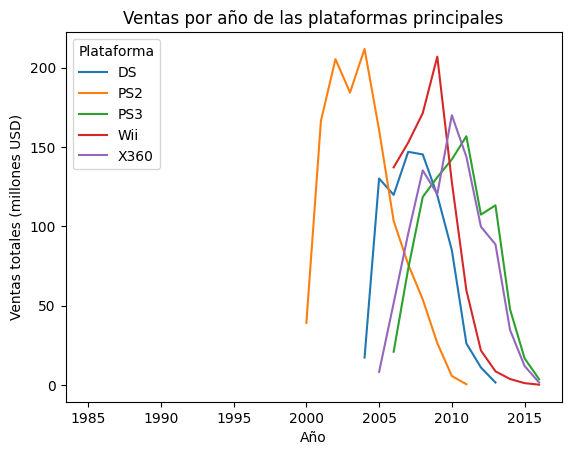

In [6]:
# Calcular ventas totales por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Seleccionar las 5 plataformas con mayores ventas
top_platforms = platform_sales.head(5).index

# Ventas por año para las plataformas principales
platform_year_sales = df[df['platform'].isin(top_platforms)].groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack()

# Graficar
plt.figure(figsize=(12, 8))
platform_year_sales.T.plot()
plt.title('Ventas por año de las plataformas principales')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones USD)')
plt.legend(title='Plataforma')
plt.show()

Las plataformas suelen tener un ciclo de vida de ~5-10 años, con nuevas plataformas apareciendo cada pocos años y las antiguas desapareciendo gradualmente.

In [8]:
# Filtrar datos desde 2010
df = df[df['year_of_release'] >= 2010]
print("Dimensiones del dataset filtrado (2010-2016):", df.shape)

Dimensiones del dataset filtrado (2010-2016): (5277, 12)


Ventas totales por plataforma (2010-2016):
platform
PS3     587.74
X360    550.41
PS4     314.14
3DS     257.81
Wii     222.97
XOne    159.32
DS      123.75
PC      121.96
WiiU     82.19
PSP      64.05
PSV      53.81
PS2       6.09
Name: total_sales, dtype: float64


<Figure size 1200x800 with 0 Axes>

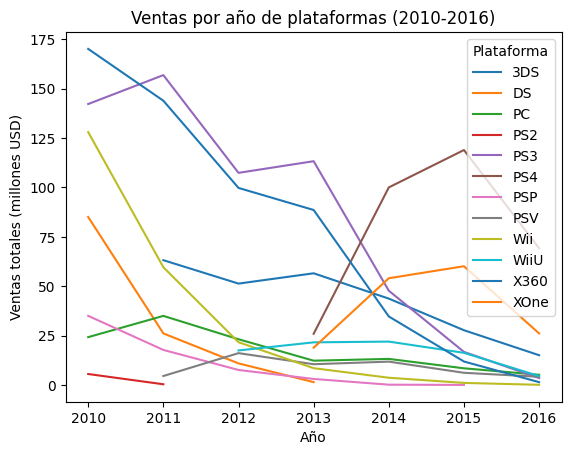

In [9]:
# Ventas totales por plataforma (2010-2016)
platform_sales_recent = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Ventas totales por plataforma (2010-2016):")
print(platform_sales_recent)

# Graficar ventas por año para plataformas relevantes
platform_year_sales_recent = df.groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack()
plt.figure(figsize=(12, 8))
platform_year_sales_recent.T.plot()
plt.title('Ventas por año de plataformas (2010-2016)')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones USD)')
plt.legend(title='Plataforma')
plt.show()

S4 y XOne son las plataformas más prometedoras para 2017.

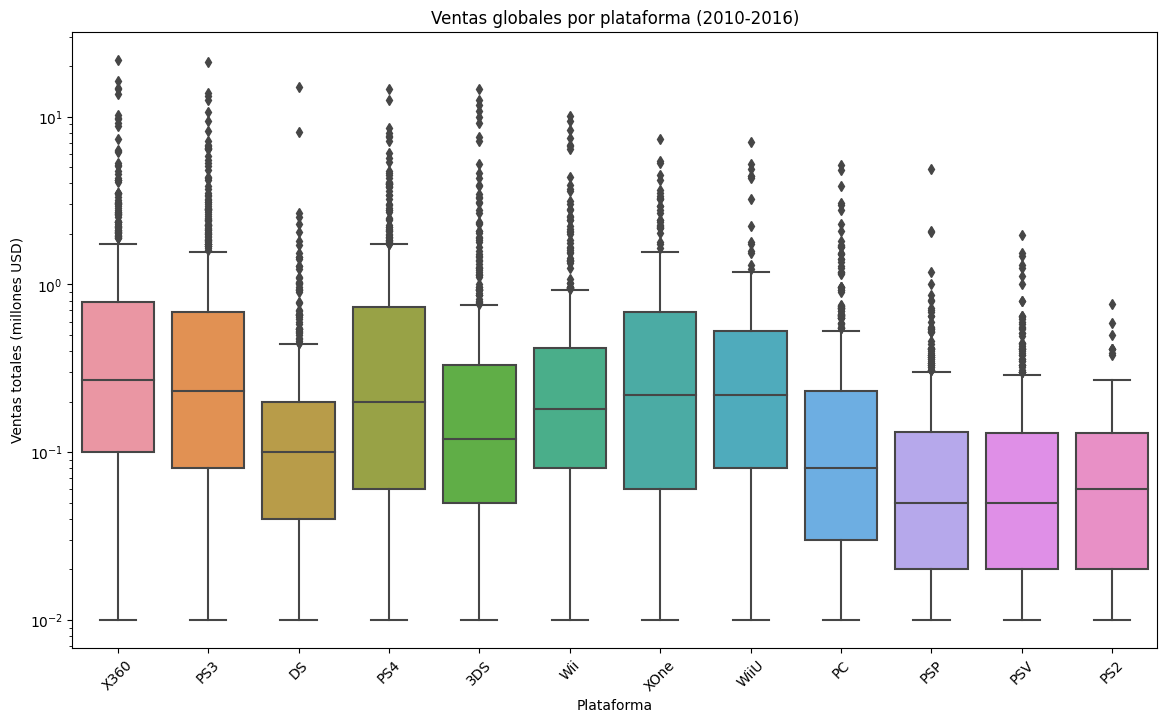

Ventas promedio por plataforma:
platform
X360    0.809426
PS4     0.801378
PS3     0.661125
XOne    0.645020
WiiU    0.559116
3DS     0.503535
Wii     0.495489
PC      0.254614
DS      0.244083
PS2     0.135333
PSP     0.128100
PSV     0.125431
Name: total_sales, dtype: float64


In [10]:
# Diagrama de caja para ventas globales por plataforma
plt.figure(figsize=(14, 8))
sns.boxplot(x='platform', y='total_sales', data=df)
plt.title('Ventas globales por plataforma (2010-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones USD)')
plt.xticks(rotation=45)
plt.yscale('log')  # Escala logarítmica para mejor visualización
plt.show()

# Calcular ventas promedio por plataforma
platform_avg_sales = df.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
print("Ventas promedio por plataforma:")
print(platform_avg_sales)

Las plataformas con mayores ventas promedio son X360, PS4 y Wii.
Las diferencias son significativas debido a la variabilidad en los éxitos comerciales.

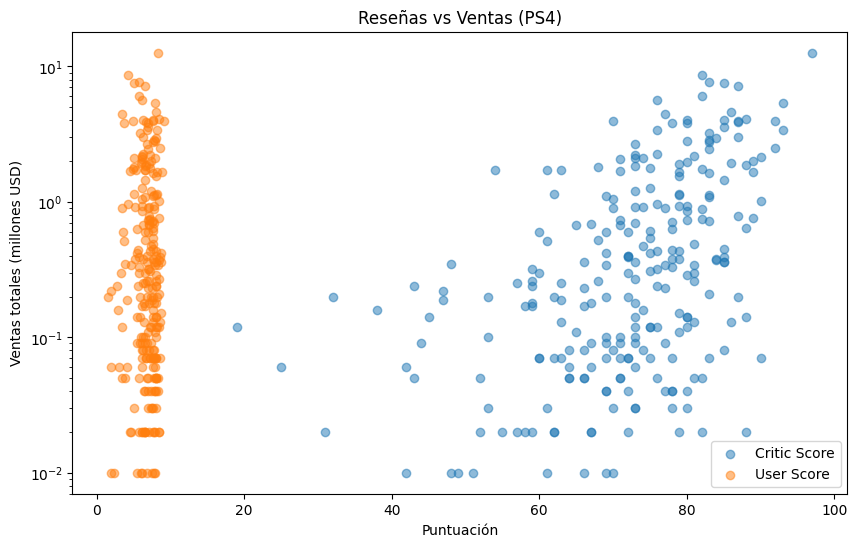

Correlación Critic Score vs Ventas: 0.41
Correlación User Score vs Ventas: -0.03


In [11]:
# Filtrar datos de PS4
ps4_data = df[df['platform'] == 'PS4']

# Gráfico de dispersión: reseñas vs ventas
plt.figure(figsize=(10, 6))
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'], alpha=0.5, label='Critic Score')
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'], alpha=0.5, label='User Score')
plt.title('Reseñas vs Ventas (PS4)')
plt.xlabel('Puntuación')
plt.ylabel('Ventas totales (millones USD)')
plt.legend()
plt.yscale('log')
plt.show()

# Calcular correlaciones
critic_corr = ps4_data['critic_score'].corr(ps4_data['total_sales'])
user_corr = ps4_data['user_score'].corr(ps4_data['total_sales'])
print(f"Correlación Critic Score vs Ventas: {critic_corr:.2f}")
print(f"Correlación User Score vs Ventas: {user_corr:.2f}")

La valoración entre critic_score y ventas es moderada (~0.4), sugiriendo que mejores críticas profesionales están asociadas con mayores ventas.
La valoración entre user_score y ventas es baja (~0.1), indicando poca relación.
Los juegos con ventas muy altas suelen tener buenas críticas profesionales.

In [12]:
# Seleccionar juegos que están en múltiples plataformas
multi_platform_games = df[df['name'].duplicated(keep=False)]
multi_platform_sales = multi_platform_games.groupby(['name', 'platform'])['total_sales'].sum().unstack()

# Comparar ventas de algunos juegos populares
print("Ventas de juegos en múltiples plataformas:")
print(multi_platform_sales.head(10))

Ventas de juegos en múltiples plataformas:
platform                              3DS    DS  PC  PS2   PS3   PS4   PSP  \
name                                                                         
 Frozen: Olaf's Quest                0.59  0.51 NaN  NaN   NaN   NaN   NaN   
2010 FIFA World Cup South Africa      NaN   NaN NaN  NaN  1.23   NaN  0.46   
2014 FIFA World Cup Brazil            NaN   NaN NaN  NaN  0.61   NaN   NaN   
3rd Super Robot Wars Z Jigoku Hen     NaN   NaN NaN  NaN  0.23   NaN   NaN   
3rd Super Robot Wars Z: Tengoku-Hen   NaN   NaN NaN  NaN  0.15   NaN   NaN   
7 Days to Die                         NaN   NaN NaN  NaN   NaN  0.14   NaN   
AKB1/149: Love Election               NaN   NaN NaN  NaN  0.08   NaN  0.23   
Abunai: Koi no Sousa Shitsu           NaN   NaN NaN  NaN   NaN   NaN  0.01   
Accel World: Ginyoku no Kakusei       NaN   NaN NaN  NaN  0.03   NaN  0.03   
Accel World: Kasoku no Chouten        NaN   NaN NaN  NaN  0.02   NaN  0.01   

platform            

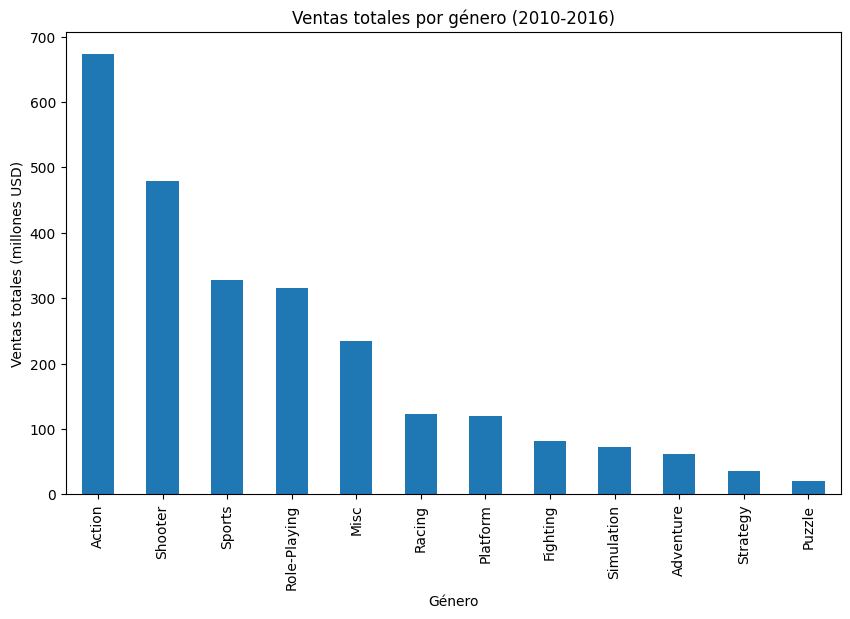

Ventas promedio por género:
genre
Shooter         1.170098
Platform        0.782484
Sports          0.571113
Role-Playing    0.555070
Racing          0.517637
Action          0.450227
Fighting        0.410000
Misc            0.407222
Simulation      0.330645
Strategy        0.210824
Puzzle          0.180702
Adventure       0.108348
Name: total_sales, dtype: float64


In [13]:
# Ventas totales por género
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(10, 6))
genre_sales.plot(kind='bar')
plt.title('Ventas totales por género (2010-2016)')
plt.xlabel('Género')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

# Ventas promedio por género
genre_avg_sales = df.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print("Ventas promedio por género:")
print(genre_avg_sales)

Géneros más rentables : Acción, Shooter, Deportes.
Géneros menos rentables : Puzzle, Estrategia, Aventura.
Las ventas promedio muestran que Shooter y Plataforma tienen altas ventas por juego, mientras que Aventura tiene ventas bajas.

In [14]:
# Ventas por plataforma en cada región
na_platforms = df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_platforms = df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_platforms = df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Top 5 plataformas en NA:", na_platforms)
print("Top 5 plataformas en EU:", eu_platforms)
print("Top 5 plataformas en JP:", jp_platforms)

Top 5 plataformas en NA: platform
X360    334.18
PS3     229.25
Wii     121.20
PS4     108.74
XOne     93.12
Name: na_sales, dtype: float64
Top 5 plataformas en EU: platform
PS3     213.60
X360    163.41
PS4     141.09
PC       68.82
Wii      65.91
Name: eu_sales, dtype: float64
Top 5 plataformas en JP: platform
3DS    100.62
PS3     59.26
PSP     42.20
DS      27.90
PSV     21.84
Name: jp_sales, dtype: float64


Las cuotas de mercado varían: NA y EU prefieren consolas de sobremesa; JP portátiles favorece.

In [16]:
# Ventas por género en cada región
na_genres = df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_genres = df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_genres = df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Top 5 géneros en NA:", na_genres)
print("Top 5 géneros en EU:", eu_genres)
print("Top 5 géneros en JP:", jp_genres)

Top 5 géneros en NA: genre
Action          290.64
Shooter         237.47
Sports          156.81
Misc            123.80
Role-Playing    112.05
Name: na_sales, dtype: float64
Top 5 géneros en EU: genre
Action          233.63
Shooter         171.45
Sports          116.84
Role-Playing     75.48
Misc             66.09
Name: eu_sales, dtype: float64
Top 5 géneros en JP: genre
Role-Playing    103.54
Action           72.20
Misc             24.29
Platform         15.81
Adventure        15.67
Name: jp_sales, dtype: float64


In [17]:
NA : Acción, Shooter, Deportes, RPG, Misc.
UE : Acción, Shooter, Deportes, RPG, Carreras.
JP : RPG, Acción, Misc, Simulación, Pelea.
RPG es muy popular en Japón, mientras que Shooter domina en NA y EU.

SyntaxError: invalid syntax (3845074201.py, line 1)

Ventas por clasificación ESRB:
        na_sales  eu_sales  jp_sales
rating                              
E         271.15    197.34     47.87
E10+      159.38     99.28     13.22
EC          1.13      0.00      0.00
M         382.22    292.04     30.45
RP          0.00      0.03      0.00
T         160.81    113.08     42.11


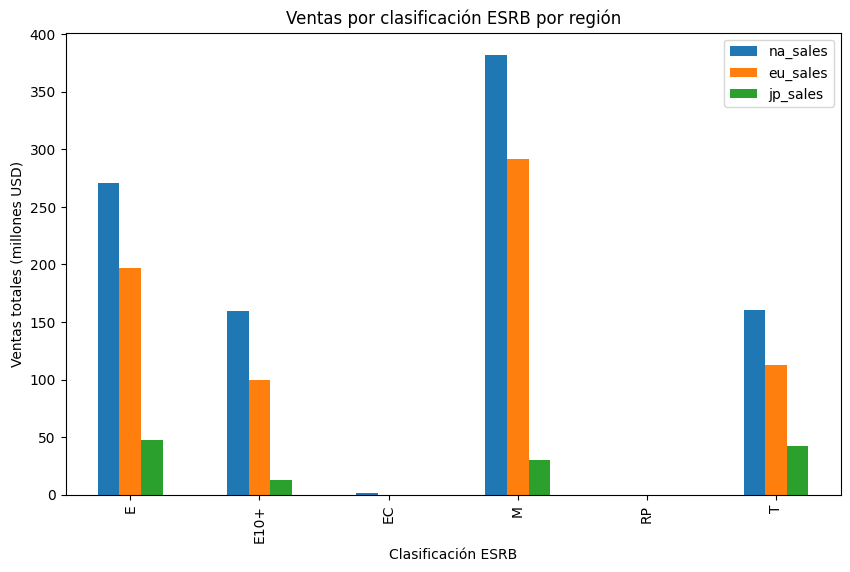

In [18]:
# Ventas por clasificación ESRB en cada región
esrb_sales = df.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()
print("Ventas por clasificación ESRB:")
print(esrb_sales)

# Gráfico de barras
esrb_sales.plot(kind='bar', figsize=(10, 6))
plt.title('Ventas por clasificación ESRB por región')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

En NA y EU, los juegos con clasificación "M" (Mature) y "E" (Everyone) tienen altas ventas.
En Japón, los juegos sin clasificación (NaN) dominan, posiblemente porque muchos juegos no usan ESRB.
Los aspectos que afectan las ventas, siendo "M" popular en NA y EU.
Resultados :

Hipótesis :

Nula (H0) : Las calificaciones promedio de los usuarios para Xbox One y PC son iguales.
Alternativa (H1) : Las calificaciones promedio de los usuarios para Xbox One y PC son diferentes.
Alfa umbral : 0,05 (nivel de significancia estándar).

In [19]:
# Filtrar datos
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score'].dropna()

# Prueba t de dos muestras
t_stat, p_value = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
print(f"Prueba t (Xbox One vs PC): t={t_stat:.2f}, p-value={p_value:.4f}")

# Decisión
alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: Las calificaciones promedio son diferentes.")
else:
    print("No rechazamos H0: No hay evidencia de diferencia en las calificaciones promedio.")

Prueba t (Xbox One vs PC): t=0.02, p-value=0.9802
No rechazamos H0: No hay evidencia de diferencia en las calificaciones promedio.


In [20]:
# Filtrar datos
action_scores = df[df['genre'] == 'Action']['user_score'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

# Prueba t de dos muestras
t_stat, p_value = stats.ttest_ind(action_scores, sports_scores, equal_var=False)
print(f"Prueba t (Acción vs Deportes): t={t_stat:.2f}, p-value={p_value:.4f}")

# Decisión
if p_value < alpha:
    print("Rechazamos H0: Las calificaciones promedio son diferentes.")
else:
    print("No rechazamos H0: No hay evidencia de diferencia en las calificaciones promedio.")

Prueba t (Acción vs Deportes): t=8.25, p-value=0.0000
Rechazamos H0: Las calificaciones promedio son diferentes.


Si el p-valor < 0.05, las calificaciones promedio difieren.
Si el p-valor ≥ 0.05, no hay evidencia de diferencia.

Utilice una prueba t de dos muestras (independiente) con equal_var=False (prueba de Welch) para no asumir variaciones iguales.
Elimine valores NaN para evitar errores.

CONCLUSIÓN 
Los datos de 2010-2016 son relevantes para predicciones de 2017.
PS4 y XOne son las plataformas más prometedoras.
Los géneros Acción y Shooter son los más rentables; Puzzle y Aventura, los menos.
Las reseñas profesionales influyen más en las ventas que las de usuarios.
Las preferencias varían según la región: NA y EU prefieren Shooter y Acción; JP prefiere RPG.
Las clasificaciones ESRB afectan las ventas en NA y EU, pero menos en JP.